# Modeling with GeoSpatial Feature

Dalam iterasi ini, kami mencoba untuk mengikutsertakan data geospatial yang diwakilkan oleh titik longitude dan latitude yang tersedia pada data.

Untuk melakukan modeling dengan data spatial ini, algoritma yang digunakan berbeda dengan XGBoost pada iterasi sebelum nya.

Algoritma yang digunakan untuk memodelkan fitur-fitur spatial ini adalah Multi-scale Geographically Weighted Regression. Metode ini dipilih karena algorimta ini cocok untuk data geospatial dengan beberapa fitur lain di dalam nya.


## Multi-Scale Geographically Weighted Regression

**Geographically Weighted Regression (GWR)** adalah metode regresi spasial yang memungkinkan hubungan antara variabel input dan target berubah di setiap lokasi geografis, sehingga model tidak memaksakan satu set koefisien yang sama untuk seluruh area studi. Teknik ini relevan untuk prediksi cadangan blue carbon karena faktor-faktor yang memengaruhi akumulasi karbon, seperti tutupan vegetasi, salinitas, curah hujan, kondisi sedimen, dan karakteristik pesisir, kemungkinan memiliki pengaruh yang berbeda di setiap wilayah. Dengan memanfaatkan informasi koordinat latitude dan longitude, GWR dapat menangkap heterogenitas spasial tersebut dan menghasilkan model yang lebih representatif dibanding regresi global yang mengasumsikan hubungan antar variabel bersifat seragam di seluruh lokasi.


## Preparation


In [1]:
# Install geopandas and contextily for base maps
!pip -q install geopandas contextily matplotlib

import geopandas
import contextily as ctx
from shapely.geometry import Point

In [2]:
# Install mgwr (Multi-scale Geographically Weighted Regression) library
!pip -q install mgwr

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading data


In [4]:
# Load the dataset
df = pd.read_csv("/content/civ_mangrove_biomass_dataset.csv")
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [5]:
df.head()

,id,su,plot,site,longitude,latitude,geometry,species,inventory_date,soil_sampling_date,...,B5,B6,B7,B8,B8A,B9,B11,B12,VV,VH
0,SU2P1,2,P1,Fresco,-5.580154,5.104702,POLYGON ((-5.580274678391799 5.104769041698510...,Palétuvier rouge (Rhizophora mangle),2025-01-15,2025-01-27,...,0.104910,0.240652,0.291560,0.283065,0.310426,0.311900,0.136974,0.073287,-7.281377,-14.540147
1,SU2P2,2,P2,Fresco,-5.580087,5.104518,POLYGON ((-5.580207516904948 5.104584347974317...,Palétuvier rouge (Rhizophora mangle),2025-01-15,2025-01-27,...,0.103887,0.250176,0.303290,0.304595,0.330112,0.311914,0.134662,0.071288,-7.105187,-14.553699
2,SU2P3,2,P3,Fresco,-5.580019,5.104331,POLYGON ((-5.580139492715077 5.104397281620796...,Palétuvier rouge (Rhizophora mangle),2025-01-15,2025-01-27,...,0.101857,0.248156,0.306091,0.308422,0.332116,0.312532,0.133510,0.070472,-6.877348,-14.702144
3,SU2P4,2,P4,Fresco,-5.579944,5.104123,POLYGON ((-5.580063875837427 5.104189335157654...,Palétuvier rouge (Rhizophora mangle),2025-01-15,2025-01-27,...,0.100532,0.243832,0.303578,0.305957,0.326306,0.311533,0.132799,0.070324,-6.504792,-14.520141
4,SU2P5,2,P5,Fresco,-5.579874,5.103932,POLYGON ((-5.579994678341312 5.103999041779242...,Palétuvier rouge (Rhizophora mangle),2025-01-15,2025-01-27,...,0.095436,0.222361,0.274195,0.251394,0.299065,0.307783,0.126838,0.068203,-6.999489,-15.366261


In [6]:
df.columns

Index(['id', 'su', 'plot', 'site', 'longitude', 'latitude', 'geometry',
       'species', 'inventory_date', 'soil_sampling_date', 'agb', 'bgb',
       'total_biomass', 'cagb', 'cbgb', 'soil_carbon_stock',
       'total_carbon_stock', 'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'B8A', 'B9', 'B11', 'B12', 'VV', 'VH'],
      dtype='object')

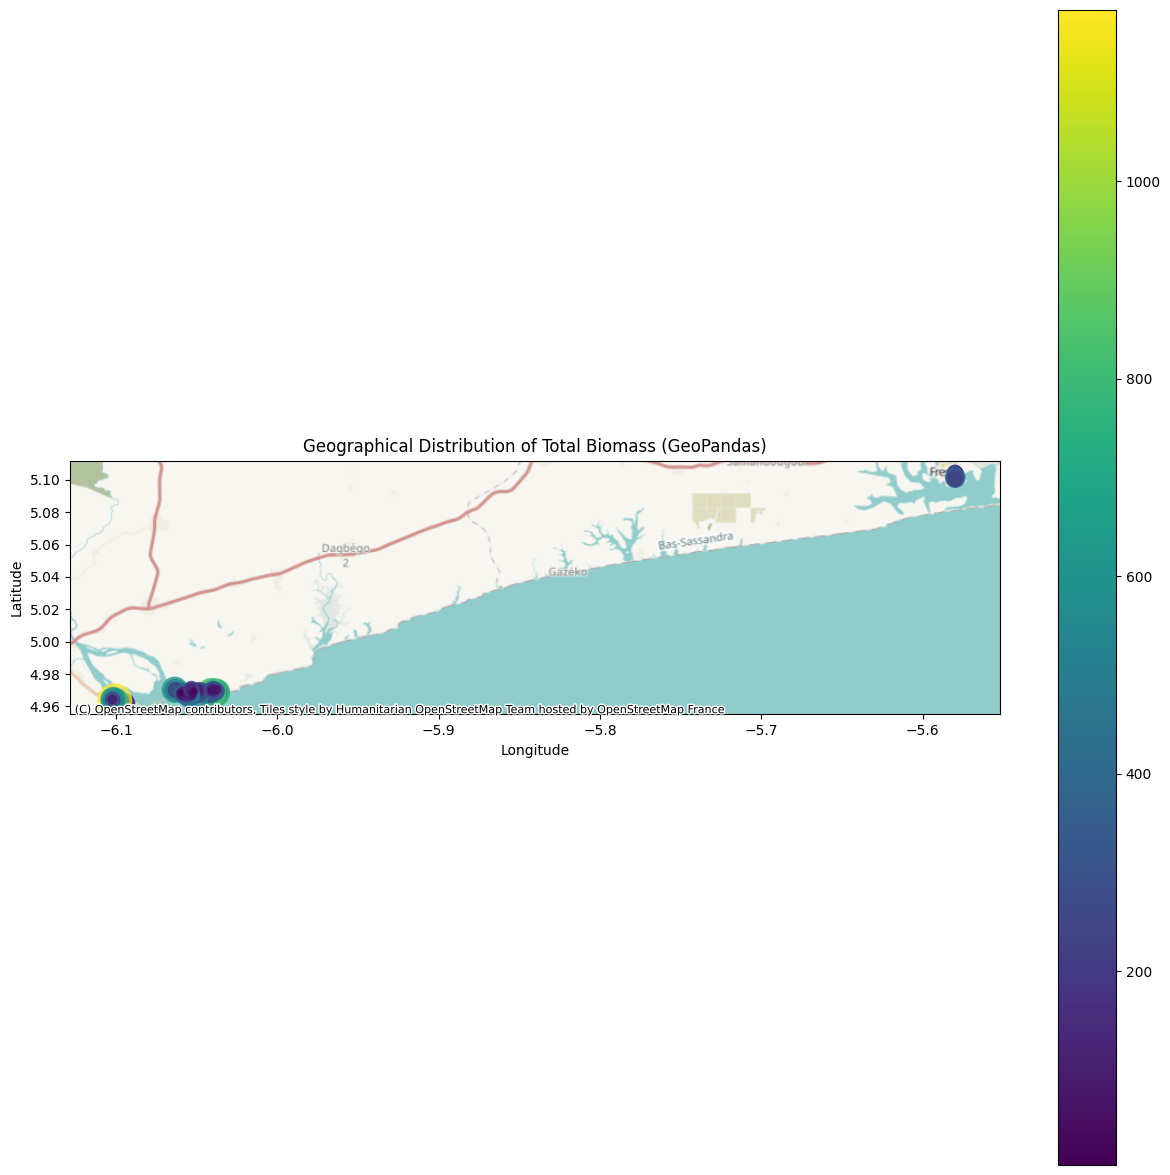

Geographical distribution plotted using GeoPandas with a base map.


In [7]:
# Create a GeoDataFrame from the DataFrame
geometry = [Point(xy) for xy in zip(df["longitude"], df["latitude"])]
gdf = geopandas.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# Plotting the geographical distribution with a base map
fig, ax = plt.subplots(figsize=(15, 15))
gdf.plot(
    ax=ax,
    column="total_biomass",
    cmap="viridis",
    markersize=gdf["total_biomass"] / 2,
    legend=True,
    alpha=0.7,
)
ctx.add_basemap(ax, crs=gdf.crs)
ax.set_title("Geographical Distribution of Total Biomass (GeoPandas)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

print("Geographical distribution plotted using GeoPandas with a base map.")

## Feature Engineering

Seperti pada iterasi sebelumnya, kami menurunkan beberapa fitur yang berguna dari proses sebelumnya.


In [14]:
# =====================================================
# FEATURE ENGINEERING
# =====================================================

# NDVI
gdf["NDVI"] = (df["B8"] - df["B4"]) / (df["B8"] + df["B4"])

# NDWI
gdf["NDWI"] = (df["B3"] - df["B8"]) / (df["B3"] + df["B8"])

# SAVI
L = 0.5

gdf["SAVI"] = ((df["B8"] - df["B4"]) * (1 + L)) / (df["B8"] + df["B4"] + L)


## Feature Selection


In [17]:
features = [
    "longitude",
    "latitude",
    "B1",
    "B2",
    "B3",
    "B4",
    "B5",
    "B6",
    "B7",
    "B8",
    "B8A",
    "B9",
    "B11",
    "B12",
    "VV",
    "VH",
    "NDVI",
    "NDWI",
    "SAVI",
]
target = "total_carbon_stock"

X = gdf[features]
y = gdf[target]

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Modeling


In [18]:
import libpysal as ps
import numpy as np
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

### Data Preparation

Transform data to fit the desired input shapes of the model.


In [19]:
# Prepare data for GWR
# GWR expects y, X, and coordinates

# Ensure X and y are numpy arrays
X_gwr = X.values
y_gwr = y.values.reshape(-1, 1)  # Reshape y to be a 2D array

# Coordinates need to be a numpy array (longitude, latitude)
coords = gdf[["longitude", "latitude"]].values

print(f"Shape of X for GWR: {X_gwr.shape}")
print(f"Shape of y for GWR: {y_gwr.shape}")
print(f"Shape of coordinates for GWR: {coords.shape}")

Shape of X for GWR: (300, 19)
Shape of y for GWR: (300, 1)
Shape of coordinates for GWR: (300, 2)


In [20]:
from sklearn.preprocessing import StandardScaler

# Standardize the features (X_gwr)
scaler = StandardScaler()
X_gwr_scaled = scaler.fit_transform(X_gwr)

print("Features (X_gwr) have been standardized.")
print(f"Shape of scaled X for GWR: {X_gwr_scaled.shape}")

Features (X_gwr) have been standardized.
Shape of scaled X for GWR: (300, 19)


In [23]:
gwr_bw = 60

print(f"Manually set GWR bandwidth (number of nearest neighbors): {gwr_bw}")

Manually set GWR bandwidth (number of nearest neighbors): 60


In [24]:
gwr_model = GWR(
    coords, y_gwr, X_gwr_scaled, bw=gwr_bw, fixed=True, kernel="gaussian", n_jobs=1
)
gwr_results = gwr_model.fit()

print("GWR model fitting attempted.")

GWR model fitting attempted.


## Model Evaluation


In [25]:
# Extract predicted values and residuals
y_pred_gwr = gwr_results.predy.reshape(-1)

# Evaluate the GWR model (on the full dataset)
r2_gwr = r2_score(y_gwr, y_pred_gwr)
mae_gwr = mean_absolute_error(y_gwr, y_pred_gwr)
mse_gwr = mean_squared_error(y_gwr, y_pred_gwr)
rmse_gwr = np.sqrt(mse_gwr)

print(f"\nModel Evaluation on Full Dataset (GWR):")
print(f"R-squared (R2): {r2_gwr:.4f}")
print(f"Mean Absolute Error (MAE): {mae_gwr:.2f}")
print(f"Mean Squared Error (MSE): {mse_gwr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_gwr:.2f}")

# Display overall GWR statistics
print("\n--- GWR Model Summary ---")
print(gwr_results.summary())


Model Evaluation on Full Dataset (GWR):
R-squared (R2): 0.3229
Mean Absolute Error (MAE): 409.97
Mean Squared Error (MSE): 439187.53
Root Mean Squared Error (RMSE): 662.71

--- GWR Model Summary ---
Model type                                                         Gaussian
Number of observations:                                                 300
Number of covariates:                                                    20

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                       131756277.516
Log-likelihood:                                                   -2374.584
AIC:                                                               4789.168
AICc:                                                              4794.491
BIC:                                                           131754680.457
R2:                                                                   0.323
Adj. R2:   

## Fine tuning

Fine tuning model menggunakan percobaan kombinasi antara hyper paramter yang digunakan dalam GWR yaitu kernel dan fixed range (fixed).

GWR menggunakan tiga buah kernal yaitu gaussian, bisquare dan exponential.


In [35]:
from mgwr.sel_bw import Sel_BW
from mgwr.gwr import GWR

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

results = []

kernels = ["gaussian", "bisquare", "exponential"]
fixed_options = [True, False]

for kernel in kernels:
    for fixed in fixed_options:
        try:
            print(f"Testing kernel={kernel}, fixed={fixed}")

            # Find optimal bandwidth
            selector = Sel_BW(coords, y_gwr, X_gwr_scaled, fixed=fixed, kernel=kernel)

            bw = selector.search(criterion="AICc")

            # Fit GWR
            gwr_model = GWR(
                coords, y_gwr, X_gwr_scaled, bw=bw, fixed=fixed, kernel=kernel, n_jobs=1
            )

            gwr_results = gwr_model.fit()

            y_pred = gwr_results.predy.reshape(-1)

            y_true = y_gwr.reshape(-1)

            r2 = r2_score(y_true, y_pred)
            mae = mean_absolute_error(y_true, y_pred)
            mse = mean_squared_error(y_true, y_pred)
            rmse = np.sqrt(mse)

            results.append(
                {
                    "kernel": kernel,
                    "fixed": fixed,
                    "bw": bw,
                    "r2": r2,
                    "mae": mae,
                    "rmse": rmse,
                    "aicc": gwr_results.aicc,
                }
            )

        except Exception as e:
            print(f"FAILED kernel={kernel}, fixed={fixed}: {e}")

results_df = pd.DataFrame(results)

print(results_df.sort_values(by="rmse", ascending=True))

Testing kernel=gaussian, fixed=True
Testing kernel=gaussian, fixed=False
Testing kernel=bisquare, fixed=True
Testing kernel=bisquare, fixed=False
Testing kernel=exponential, fixed=True
Testing kernel=exponential, fixed=False
        kernel  fixed      bw        r2         mae        rmse         aicc
3     bisquare  False  238.00  0.486188  335.637845  577.318841  4805.615153
5  exponential  False  160.00  0.461458  340.190444  591.049165  4777.073706
1     gaussian  False  109.00  0.450308  339.553768  597.136223  4783.724948
4  exponential   True    1.08  0.325893  408.747262  661.269001  4794.833294
2     bisquare   True    1.08  0.324178  409.520974  662.109539  4795.225760
0     gaussian   True    1.08  0.323234  409.865006  662.571797  4794.644375
